In [13]:
import warnings
warnings.filterwarnings("ignore")

import astropy.io.fits as fits
import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import os
import pandas as pd
import glob

from create_figs import create_m0_map, mark_sources_2, plot_vector, mark_sources

In [14]:
# script options
overwrite = False
output_folder = "../results/master_fig"

# read data
df = pd.read_csv('../data/output/outflow_data.csv')
source_info = pd.read_csv("../data/output/source_info.csv")
source_info['Main'] = source_info['Main'].apply(lambda x: str(x).casefold())
source_info.set_index('Main', inplace=True)

# helper function to extract channel indices from the data table
def getIdx(listOf):
    ranges = []
    
    for string in listOf:
        if pd.isna(string):  # Skip NaN values
            continue
        
        for part in string.split(', '):
            if '-' in part:  # Handle ranges
                start, end = map(int, part.split('-'))
                ranges.append(np.r_[start:end + 1])  # Use np.r_
            else:  # Handle single values
                ranges.append(int(part))  # Append as integer
    
    # Ensure `ranges` is not empty before passing to np.r_
    if not ranges:
        return np.r_[:]  # Returns an empty np.r_

    return np.r_[tuple(ranges)]  # Use `tuple(ranges)` to avoid errors

In [21]:
def make_compound_plots(data, output_name, figsize, rows, cols, wspace, hspace):
    figure = plt.figure(figsize=figsize)

    # This loops through each source field with an angle measurement and creates
    # a figure with the separation vector and outflow vector overlayed
    for i, field in data.groupby('field').agg('first').reset_index().iterrows():

        # verify output path exists and
        # skip already existing files if you don't want to overwrite them
        target_name = field['field']

        # verify output path exists and
        if not os.path.exists(output_folder):
            os.mkdir(output_folder)

        # open image
        image_filename = (glob.glob(f'/Volumes/Alpha/Research/data/{target_name.casefold()}/*12co*.fits') + glob.glob(f'/Volumes/Alpha/Research/data/{target_name.casefold()}/*spw39*.fits'))[0]
        hdulist = fits.open(image_filename)    
        hdu = hdulist[0]

        # set center and size of cutout
        center = SkyCoord(hdu.header['OBSRA'], hdu.header['OBSDEC'], unit=u.degree)
        size = np.array([39, 39]) * u.arcsecond
        distance = field['distance']

        # create figure
        channels = getIdx([field['red_channels'], field['blue_channels']])
        fig = create_m0_map(hdu, center, size, channels, 3, distance, figure, subplot=(rows, cols, i+1), multiimage=True)
        fig.set_title(f"{target_name}")

        ### VECTORS
        # plot binary separation angle
        center_origin = np.array([np.mean([field['source_a_ra'], field['source_b_ra']]), np.mean([field['source_a_dec'], field['source_b_dec']])])
        separation_angle_north = field['binary_PA']
        # draw separation vector in both directions
        plot_vector(fig, center_origin, separation_angle_north, color='white', length=0.005)
        plot_vector(fig, center_origin, separation_angle_north + 180, color='white', length=0.005)
        
        # plot each outflow vector
        for j, source in df[df['field'] == target_name].reset_index(drop=True).iterrows():
            # define vector origin at the outflow source
            if source['outflow_source'] == 'both':
                outflow_origin = center_origin
            elif source['outflow_source'] == source['source_a']:
                outflow_origin = np.array([source['source_a_ra'], source['source_a_dec']])
            else:
                outflow_origin = np.array([source['source_b_ra'], source['source_b_dec']])

            # plot outflow vector
            outflow_angle_north = source['outflow_PA']
            plot_vector(fig, outflow_origin, outflow_angle_north, color='red', length=0.005)
            
            # calculate delta_PA
            angle = np.abs(outflow_angle_north - separation_angle_north) % 180
            angle = np.min([angle, 180 - angle])
                
            # display angle between outflow and separation in top left corner
            # source_label = source['outflow_source']
            # if source_label == 'both':
            #     source_label = source['source_a']+'+'+source['source_b']
            # fig.ax.text(25,fig.ax.get_xlim()[1]-55-50*(j), f"{source_label} : {np.abs(angle):.2f}°", fontdict={'fontsize': 6})

        # manage axis labels
        if i % cols != 3:
            fig.colorbar.set_axis_label_text("")

        if i % cols != 0:
            fig.axis_labels.hide_y()

        if (rows > 1) & (i < rows*cols - cols):
            fig.axis_labels.hide_x()

        ### MARKERS
        # add a marker at each source with legend
        target_info = source_info.loc[target_name.casefold()]
        mark_sources(fig, target_info, use_short_label=True)

    plt.subplots_adjust(wspace=wspace, hspace=hspace)

    # save image
    figure.savefig(os.path.join(output_folder, f"{output_name}.pdf"))
    figure.savefig(os.path.join(output_folder, f"{output_name}.png"), dpi=800, transparent=True, bbox_inches='tight')
    figure.show()


In [15]:
fig_1 = ['HOPS-32', 'HOPS-168', 'HOPS-281', 'Per-emb-17']
df_fig1 = df[df['field'].isin(fig_1)]
df_fig1 = df_fig1.sort_values(by='source_a_ra', ascending=True)

fig_2 = ['HOPS-290', 'HOPS-288']
df_fig2 = df[df['field'].isin(fig_2)]
df_fig2 = df_fig2.sort_values(by='source_a_ra', ascending=True)

INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  2.400e-01 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  1.170e-01 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  3.681e-02 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  2.770e-01 [aplpy.core]


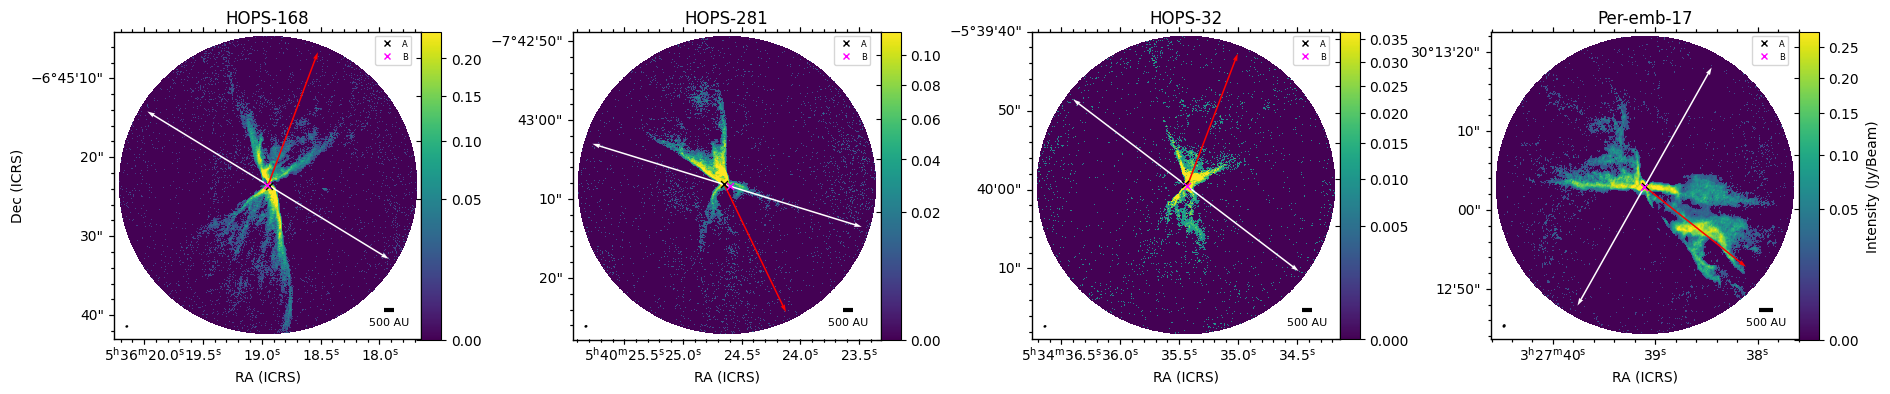

In [22]:
make_compound_plots(df_fig1, "fig_1", figsize=(22,10), rows=1, cols=4, wspace=0.4, hspace=0.1)

INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  1.463e-01 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  1.105e-01 [aplpy.core]


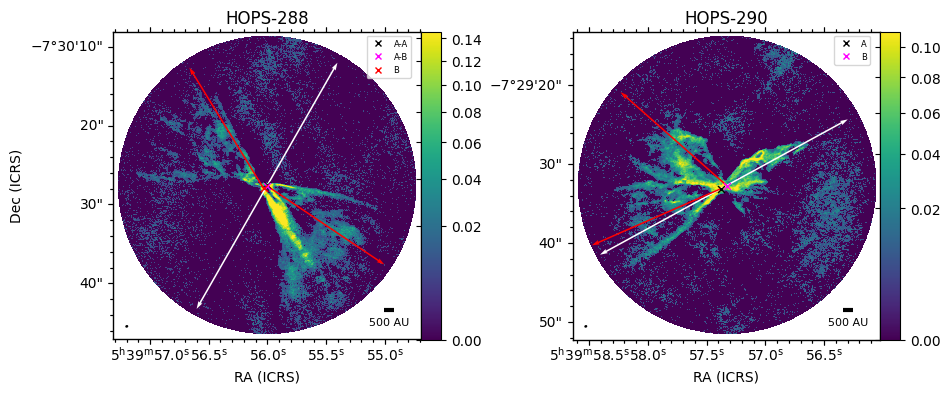

In [24]:
make_compound_plots(df_fig2, "fig_2", figsize=(22,10), rows=1, cols=4, wspace=0.4, hspace=0.1)

In [ ]:
# binaries with one outflow (27) (M0)
app1 = ['HH270VLA1', 'HOPS-32', 'HOPS-75', 'HOPS-84', 'HOPS-168', 'HOPS-173', 'HOPS-182', 'HOPS-193', 'HOPS-213', 'HOPS-281', 'HOPS-282', 'HOPS-304', 'HOPS-312', 'HOPS-323', 'HOPS-361-N']
app2 = ['HOPS-363', 'HOPS-364', 'HOPS-366', 'HOPS-384', 'HOPS-395', 'HOPS-400', 'Per-emb-2', 'Per-emb-17', 'Per-emb-18', 'Per-emb-22', 'Per-emb-36', 'Per-emb-44']
# binaries with two outflows (4) (M0)
app3 = ['HOPS-290', 'Per-emb-12', 'Per-emb-27', 'Per-emb-35']
# hierarchical triples with two outflows (5) (M0)
app4 = ['HOPS-12', 'HOPS-92', 'HOPS-203', 'HOPS-288', 'Per-emb-33']
# unmeasured complex structures (8) (M8)
app5 = ['HOPS-56', 'HOPS-70', 'HOPS-261', 'HOPS-158', 'HOPS-138', 'HOPS-45', 'HOPS-85', 'HOPS-77']
# unmeasured no outflow (6) (M8)
app6 = ['HOPS-28', 'HOPS-163', 'HOPS-242', 'HOPS-248', 'HOPS-255', 'HOPS-357']


df_app1 = df[df['field'].isin(app1)]
df_app1 = df_app1.sort_values(by='source_a_ra', ascending=True)

INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  2.750e-01 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  2.326e-01 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  8.817e-03 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  2.198e-01 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  1.531e-02 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  2.223e-02 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  1.274e-01 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  1.893e-02 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  1.264e-01 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  6.5

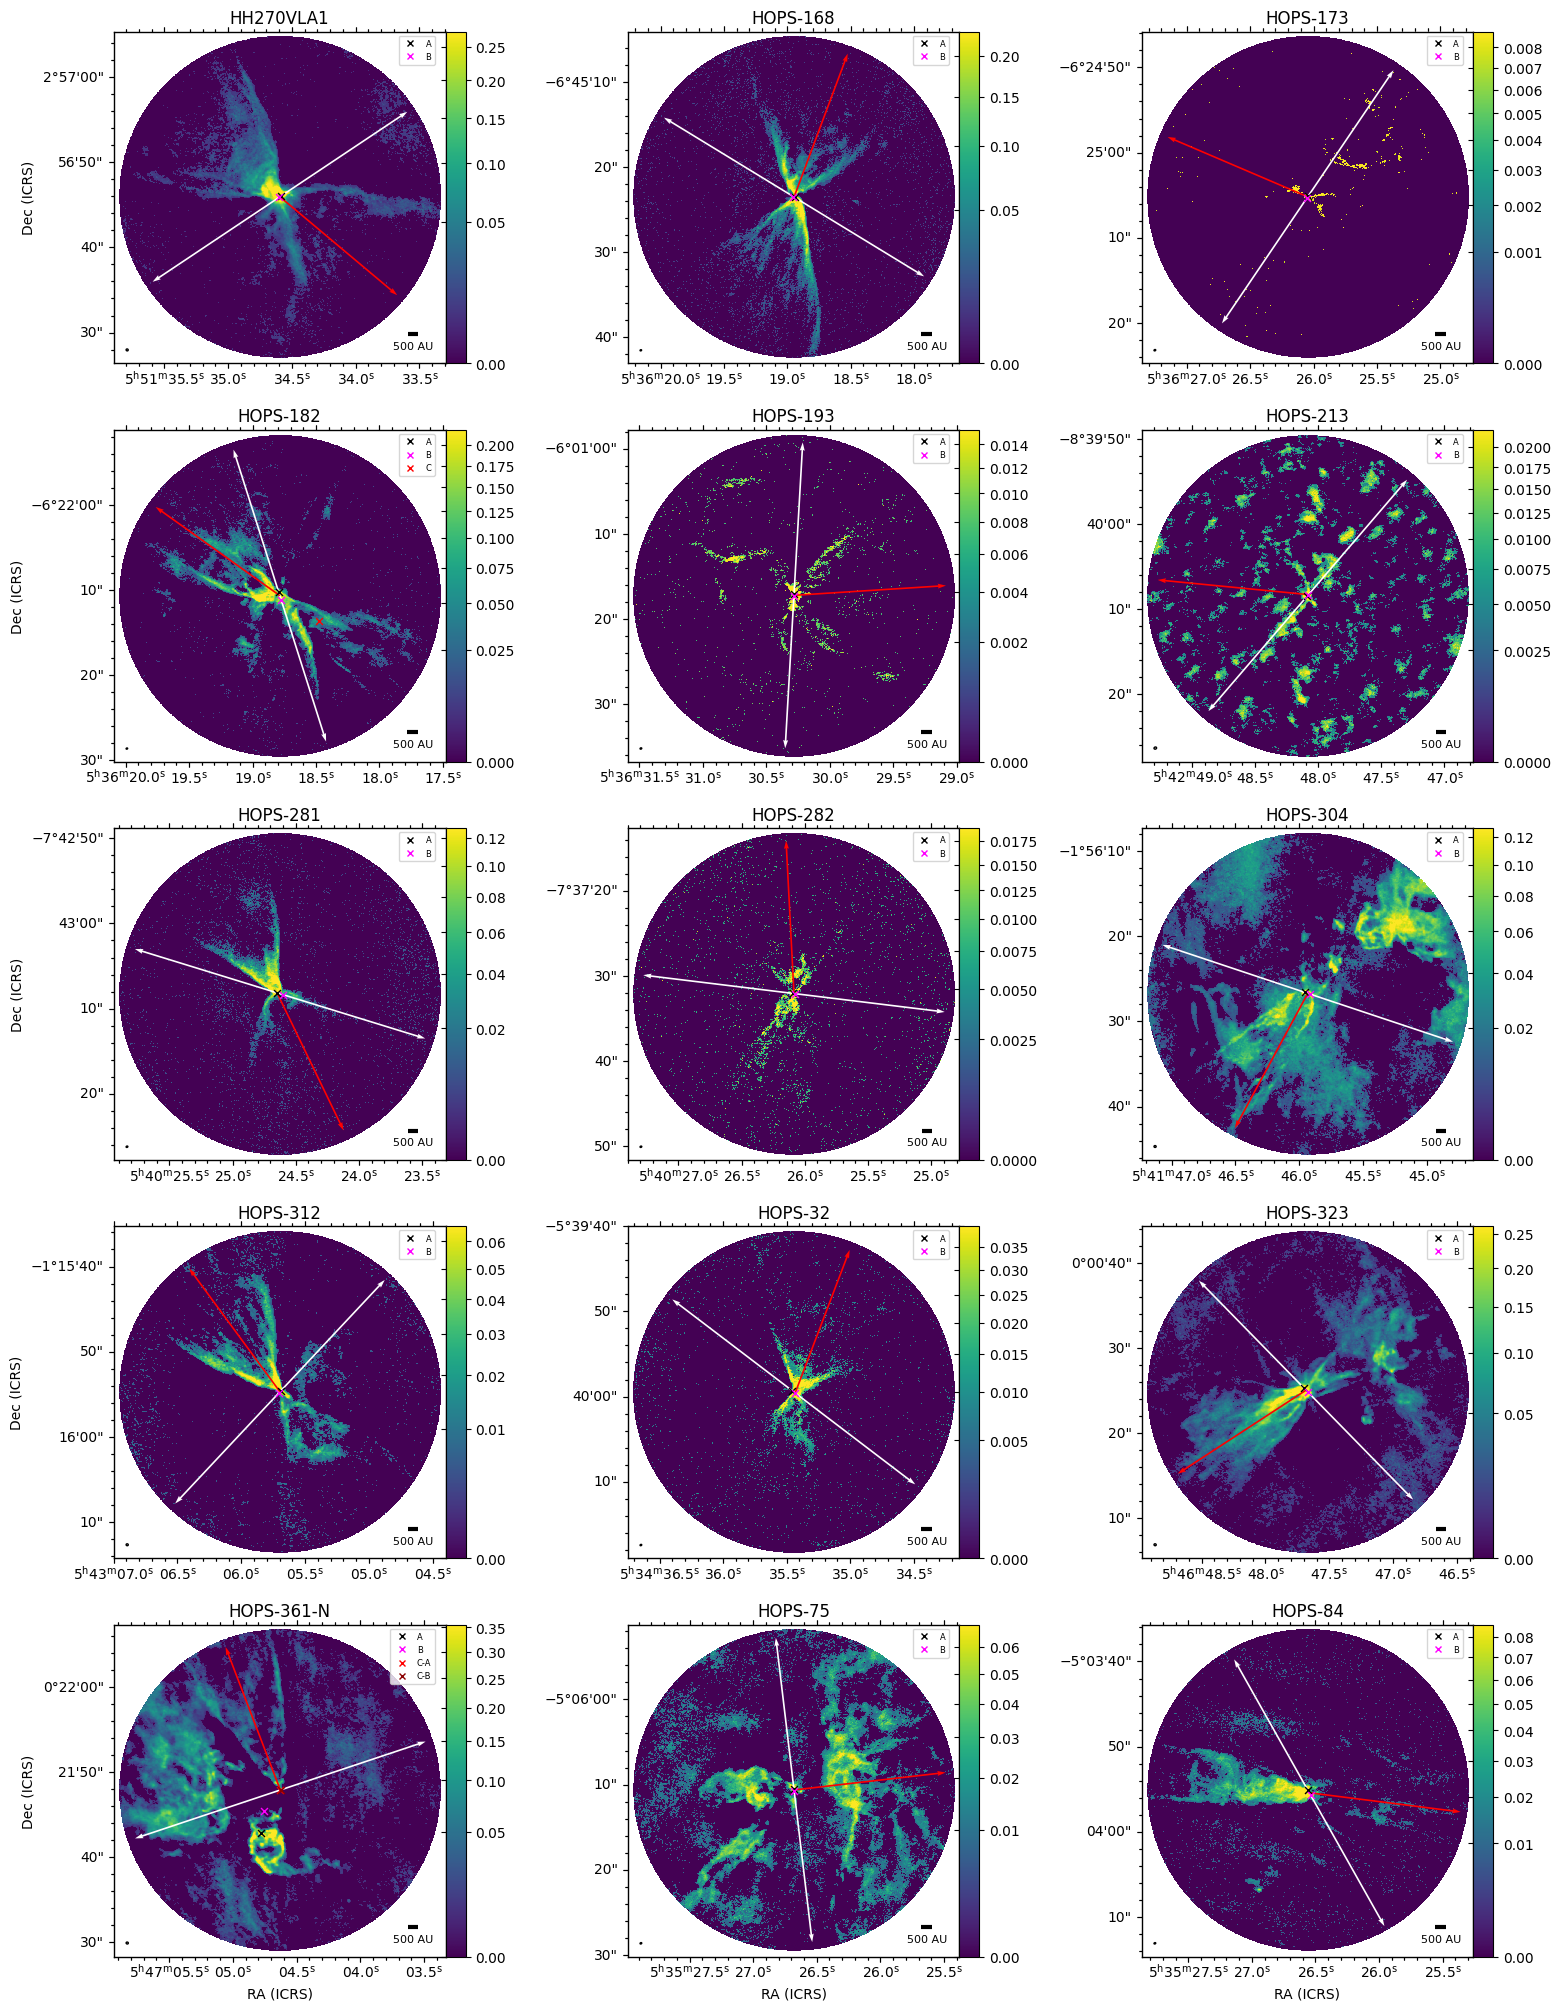

In [29]:
make_compound_plots(df_app1, "app1", figsize=(18,25), rows=5, cols=3, wspace=0.4, hspace=0.2)